# Step 1: Perform EDA analysis for California-housing dataset

## Import Libraries and Load Data

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


## Load California housing dataset as DataFrame

In [2]:
df_cal_housing = fetch_california_housing(as_frame=True)
california_df = df_cal_housing.frame  # The DataFrame itself

### Display dataset info

In [3]:
print(f"Dataset Shape: {california_df.shape}")
print("\nFirst 5 Rows of the Dataset:")
print(california_df.head())



Dataset Shape: (20640, 9)

First 5 Rows of the Dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


### Check for missing values and data types

In [4]:
print("\nDataset Info:")
print(california_df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


## Descriptive Statistics

Here, we will be able to have the picture of the statistical view of the dataset.

In [5]:
print("\nDescriptive Statistics:")
print(california_df.describe().T)


Descriptive Statistics:
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716   
AveBedrms    20640.0     1.096675     0.473911    0.333333    1.006079   
Population   20640.0  1425.476744  1132.462122    3.000000  787.000000   
AveOccup     20640.0     3.070655    10.386050    0.692308    2.429741   
Latitude     20640.0    35.631861     2.135952   32.540000   33.930000   
Longitude    20640.0  -119.569704     2.003532 -124.350000 -121.800000   
MedHouseVal  20640.0     2.068558     1.153956    0.149990    1.196000   

                     50%          75%           max  
MedInc          3.534800     4.743250     15.000100  
HouseAge       29.000000    37.000000     52.000000  
AveRooms        5.229129     6.052381    141.909091  
AveBedrms       1.

## Target Variable Analysis

The target variable is right-skewed.
Right-skewed distribution, also known as a positively skewed distribution, is a statistical pattern where the majority of data points cluster on the left side of the distribution, while a smaller number of high values extend the tail on the right side.

### Histogram

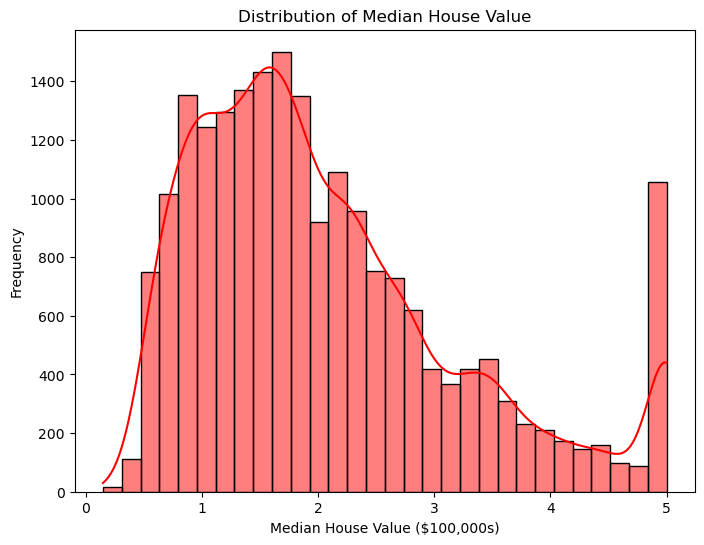

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram of Median House Value
plt.figure(figsize=(8, 6))
sns.histplot(california_df['MedHouseVal'], kde=True, color='red', bins=30)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Frequency")
plt.show()


### Boxplot

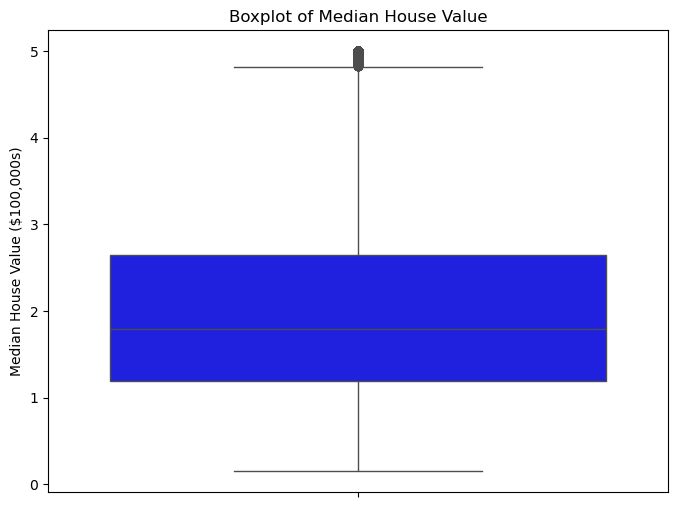

In [12]:
# Boxplot for Median House Value
plt.figure(figsize=(8, 6))
sns.boxplot(y=california_df['MedHouseVal'], color='blue')
plt.title("Boxplot of Median House Value")
plt.ylabel("Median House Value ($100,000s)")
plt.show()


## Feature Distributions

### Histograms

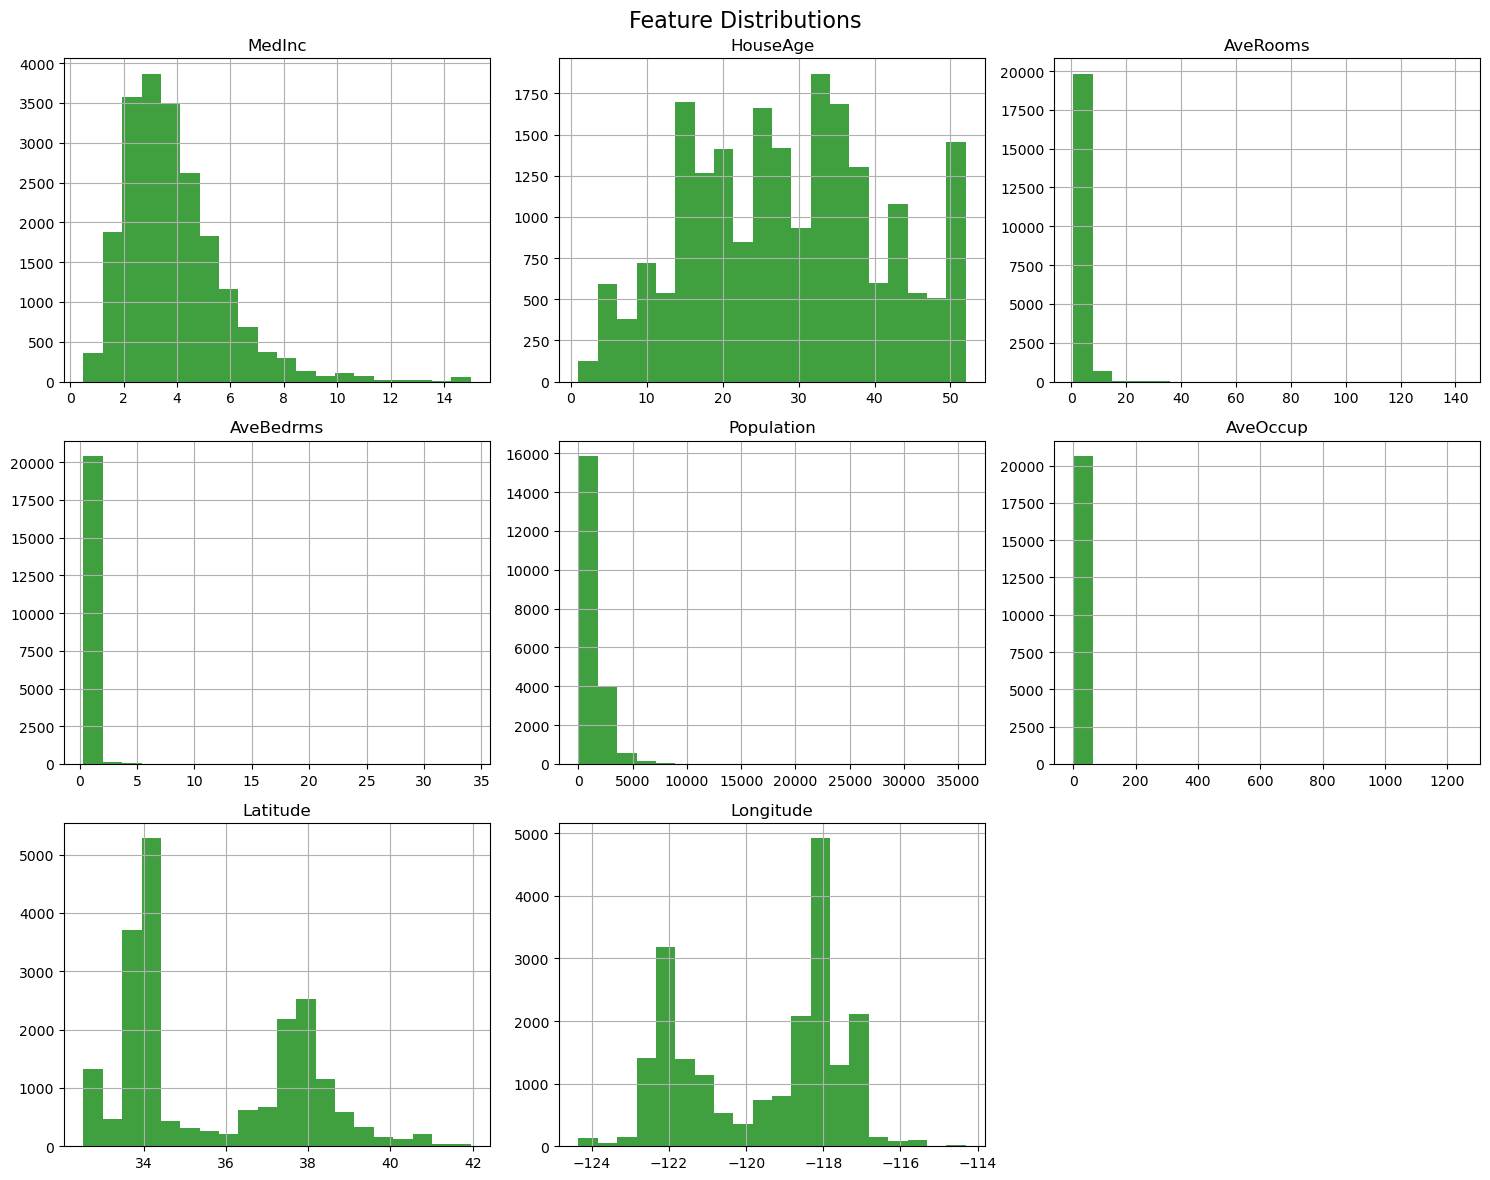

In [15]:
# Histograms of all features
california_df.iloc[:, :-1].hist(bins=20, figsize=(15, 12), color='green', alpha=0.75)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


### Density Plot

Potential outliers in AveRooms and AveOccup

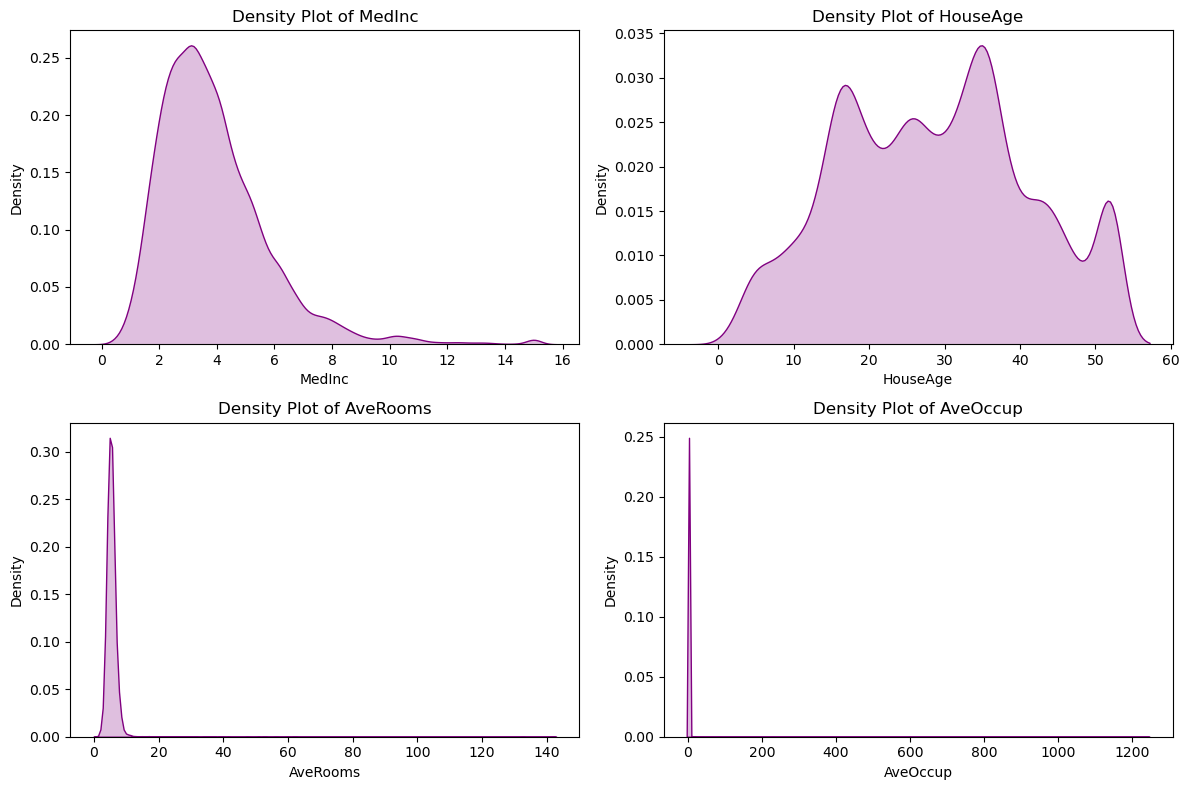

In [18]:
# Density plots for selected features
selected_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(california_df[feature], fill=True, color='purple')
    plt.title(f"Density Plot of {feature}")
plt.tight_layout()
plt.show()


## Correlation Analysis

MedInc is the strongest predictor of MedHouseVal.
Weak correlations for AveRooms and AveOccup with the target.

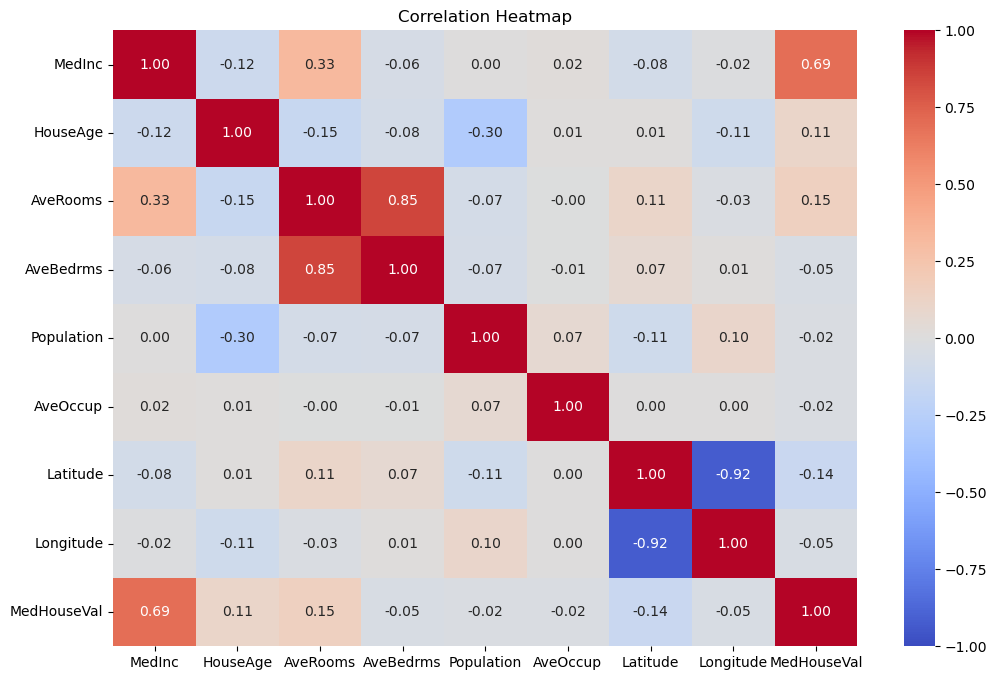

In [19]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(california_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


## Geospatial Analysis

### Scatter Plot by Latitude and Longitude

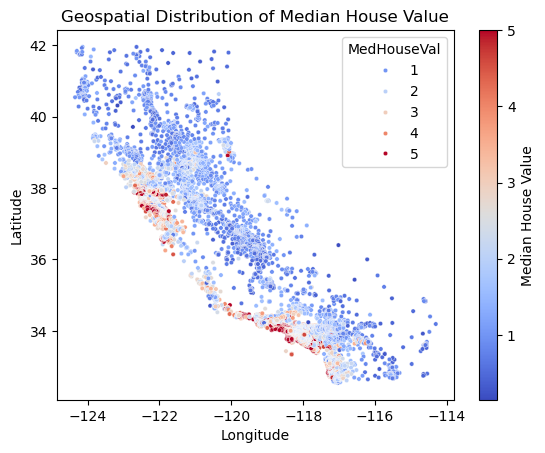

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
import numpy as np

# Create the scatter plot with hue as the 'MedHouseVal'
scatter = sns.scatterplot(x=california_df['Longitude'], y=california_df['Latitude'], 
                          hue=california_df['MedHouseVal'], palette='coolwarm', s=10)

# Get the current axes for the scatter plot
ax = plt.gca()

# Create a ScalarMappable with the same colormap and normalization
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=california_df['MedHouseVal'].min(), vmax=california_df['MedHouseVal'].max()))
sm.set_array([])  # Needed to make the ScalarMappable work

# Add the colorbar using the same axes as the scatter plot
plt.colorbar(sm, ax=ax, label="Median House Value")

# Set plot labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geospatial Distribution of Median House Value")

plt.show()


### Coastal vs. Inland Analysis

Coastal areas have significantly higher median house values compared to inland regions.

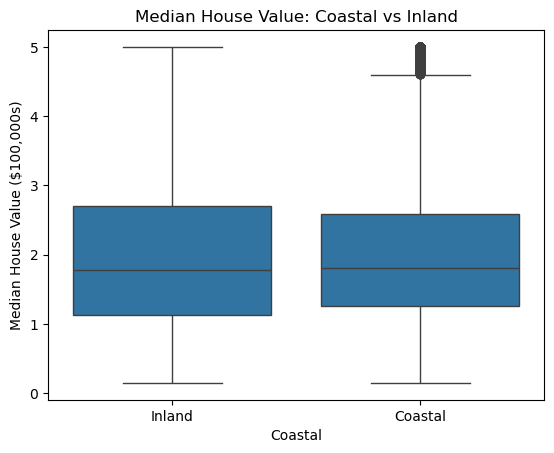

In [24]:
# Define Coastal/Inland
california_df['Coastal'] = california_df['Longitude'].apply(lambda x: 'Coastal' if x > -120 else 'Inland')

# Boxplot for Coastal vs Inland
sns.boxplot(x='Coastal', y='MedHouseVal', data=california_df)
plt.title("Median House Value: Coastal vs Inland")
plt.ylabel("Median House Value ($100,000s)")
plt.show()


## Outlier Detection

### Boxplots for Key Features

AveRooms and AveOccup contain extreme outliers

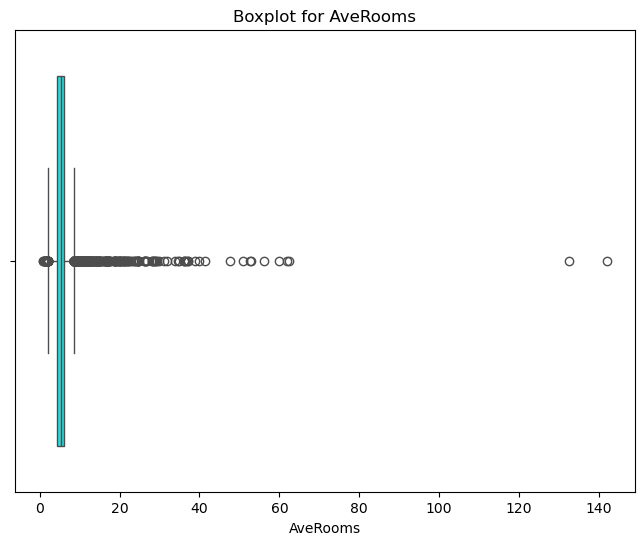

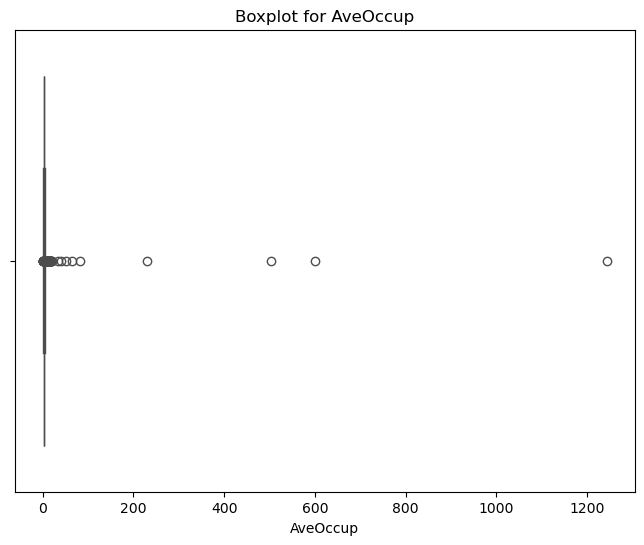

In [25]:
# Boxplots for outlier detection
outlier_features = ['AveRooms', 'AveOccup']
for feature in outlier_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=california_df[feature], color='cyan')
    plt.title(f"Boxplot for {feature}")
    plt.xlabel(feature)
    plt.show()


### Handling Outliers

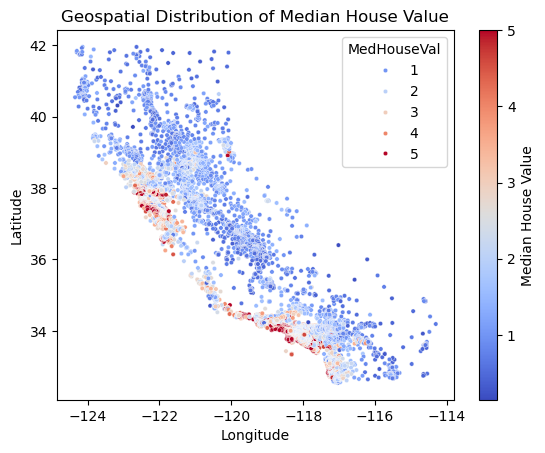

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
import numpy as np

# Handle outliers by capping values in AveRooms and AveOccup at the 99th percentile
for feature in ['AveRooms', 'AveOccup']:
    # Get the 99th percentile
    percentile_99 = california_df[feature].quantile(0.99)
    # Cap the values at the 99th percentile
    california_df[feature] = california_df[feature].clip(upper=percentile_99)

# Create the scatter plot with hue as the 'MedHouseVal'
scatter = sns.scatterplot(x=california_df['Longitude'], y=california_df['Latitude'], 
                          hue=california_df['MedHouseVal'], palette='coolwarm', s=10)

# Get the current axes for the scatter plot
ax = plt.gca()

# Create a ScalarMappable with the same colormap and normalization
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=california_df['MedHouseVal'].min(), vmax=california_df['MedHouseVal'].max()))
sm.set_array([])  # Needed to make the ScalarMappable work

# Add the colorbar using the same axes as the scatter plot
plt.colorbar(sm, ax=ax, label="Median House Value")

# Set plot labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geospatial Distribution of Median House Value")

plt.show()


## Feature-Target Relationships

### Scatterplots of important features

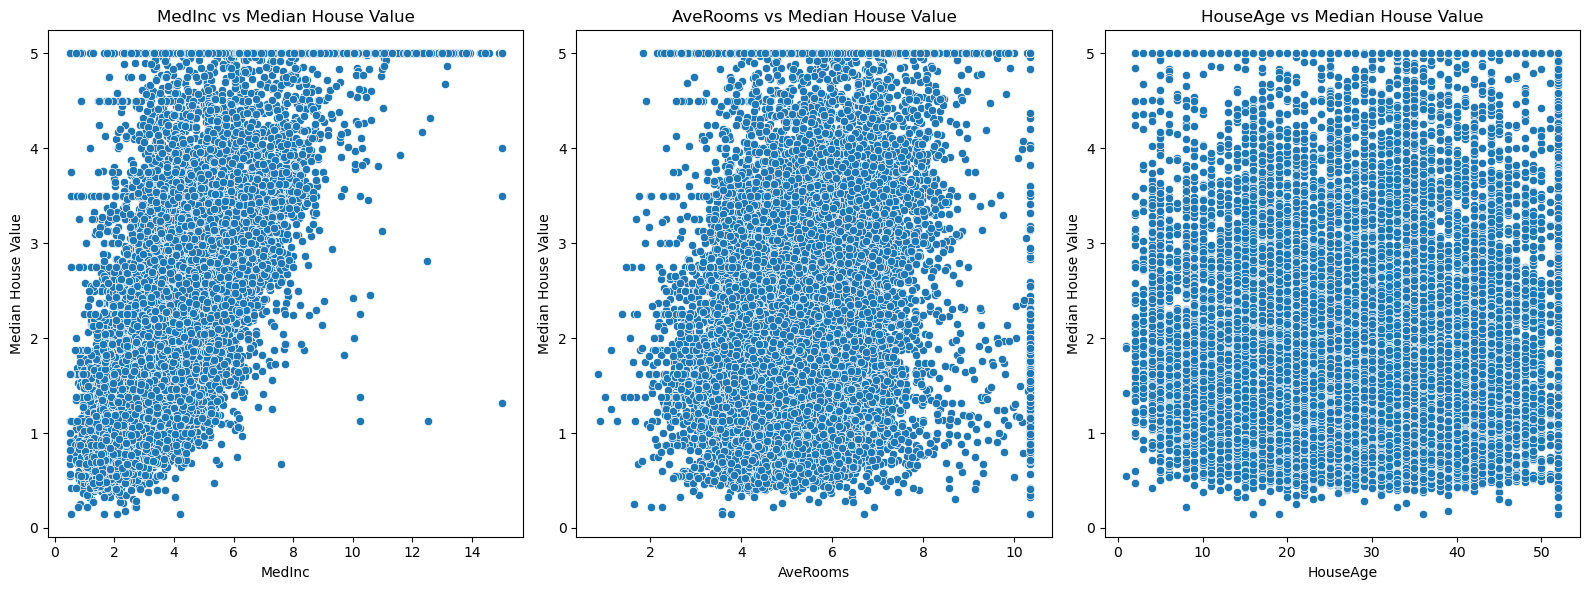

In [28]:
important_features = ['MedInc', 'AveRooms', 'HouseAge']
plt.figure(figsize=(16, 6))
for i, feature in enumerate(important_features, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=california_df[feature], y=california_df['MedHouseVal'])
    plt.title(f"{feature} vs Median House Value")
    plt.xlabel(feature)
    plt.ylabel("Median House Value")
plt.tight_layout()
plt.show()


### Binned Boxplots

MedInc has a strong positive linear relationship with MedHouseVal.
Higher income bins correspond to higher median house values.

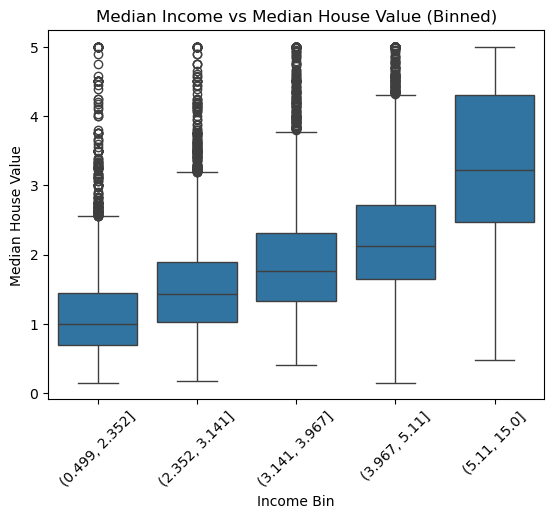

In [29]:
# Group Median Income into bins
california_df['IncomeBin'] = pd.qcut(california_df['MedInc'], q=5)

sns.boxplot(x='IncomeBin', y='MedHouseVal', data=california_df)
plt.title("Median Income vs Median House Value (Binned)")
plt.xlabel("Income Bin")
plt.ylabel("Median House Value")
plt.xticks(rotation=45)
plt.show()


## Transformations

Log transformation reduces skewness in the target variable.

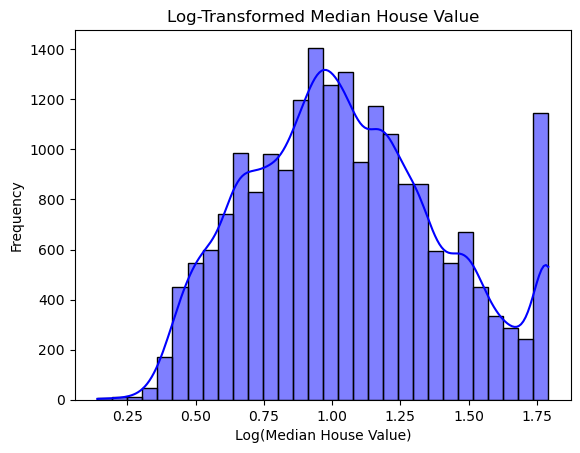

In [31]:
import numpy as np

# Apply log transformation to target
california_df['LogMedHouseVal'] = np.log1p(california_df['MedHouseVal'])

sns.histplot(california_df['LogMedHouseVal'], kde=True, color='blue', bins=30)
plt.title("Log-Transformed Median House Value")
plt.xlabel("Log(Median House Value)")
plt.ylabel("Frequency")
plt.show()


4_ Perform regression analysis task on the California-housing dataset, utilizing both 
DTRegressor and RandomRegressor with their default parameters. Which one performs 
better? Print out their respective Mean-Squared Error (MSE) and Coefficient of 
Determination (R-squared, R^2) 2) 

In [38]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
df_cal_housing = fetch_california_housing(as_frame=True)
california_df = df_cal_housing.frame

# Features and target variable
X = california_df.drop(columns=['MedHouseVal'])  # Drop the target column
y = california_df['MedHouseVal']  # Target: Median House Value

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Decision Tree Regressor (default parameters)
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

# Predictions for Decision Tree
y_pred_dt = dt_regressor.predict(X_test)

# 2. Random Forest Regressor (default parameters)
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_train, y_train)

# Predictions for Random Forest
y_pred_rf = rf_regressor.predict(X_test)

# 3. Evaluate models using MSE and R²
# Decision Tree Regressor Evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Random Forest Regressor Evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Print the evaluation results
print("Decision Tree Regressor (Default Parameters):")
print(f"Mean Squared Error (MSE): {mse_dt:.4f}")
print(f"R²: {r2_dt:.4f}\n")

print("Random Forest Regressor (Default Parameters):")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")


Decision Tree Regressor (Default Parameters):
Mean Squared Error (MSE): 0.4952
R²: 0.6221

Random Forest Regressor (Default Parameters):
Mean Squared Error (MSE): 0.2554
R²: 0.8051


5_ Perform same task as #3, but now tune the regressors. Which one performs better? 
Print out their respective Mean-Squared Error (MSE) and Coefficient of Determination 
(R-squared, R^2) 

In [39]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
df_cal_housing = fetch_california_housing(as_frame=True)
california_df = df_cal_housing.frame

# Features and target variable
X = california_df.drop(columns=['MedHouseVal'])  # Drop the target column
y = california_df['MedHouseVal']  # Target: Median House Value

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Decision Tree Regressor (Hyperparameter tuning with GridSearchCV)
dt_param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_regressor = DecisionTreeRegressor(random_state=42)
dt_grid_search = GridSearchCV(dt_regressor, dt_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
dt_grid_search.fit(X_train, y_train)

# Best Decision Tree model from GridSearchCV
best_dt = dt_grid_search.best_estimator_

# Predictions for Decision Tree
y_pred_dt = best_dt.predict(X_test)

# 2. Random Forest Regressor (Hyperparameter tuning with GridSearchCV)
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_regressor = RandomForestRegressor(random_state=42)
rf_grid_search = GridSearchCV(rf_regressor, rf_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

# Best Random Forest model from GridSearchCV
best_rf = rf_grid_search.best_estimator_

# Predictions for Random Forest
y_pred_rf = best_rf.predict(X_test)

# 3. Evaluate models using MSE and R²
# Decision Tree Regressor Evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Random Forest Regressor Evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Print the evaluation results
print("Tuned Decision Tree Regressor:")
print(f"Mean Squared Error (MSE): {mse_dt:.4f}")
print(f"R²: {r2_dt:.4f}\n")

print("Tuned Random Forest Regressor:")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")


Tuned Decision Tree Regressor:
Mean Squared Error (MSE): 0.4083
R²: 0.6884

Tuned Random Forest Regressor:
Mean Squared Error (MSE): 0.2547
R²: 0.8057


From the above result we can conclude that Random Forest Regressor is the model which performs better.

### 4. Print Feature Importance for both models

In [41]:
# Feature Importance for Decision Tree
print("\nFeature Importance for Decision Tree Regressor:")
dt_feature_importance = best_dt.feature_importances_
for feature, importance in zip(X.columns, dt_feature_importance):
    print(f"{feature}: {importance:.4f}")

# Feature Importance for Random Forest
print("\nFeature Importance for Random Forest Regressor:")
rf_feature_importance = best_rf.feature_importances_
for feature, importance in zip(X.columns, rf_feature_importance):
    print(f"{feature}: {importance:.4f}")


Feature Importance for Decision Tree Regressor:
MedInc: 0.6177
HouseAge: 0.0449
AveRooms: 0.0372
AveBedrms: 0.0118
Population: 0.0130
AveOccup: 0.1311
Latitude: 0.0778
Longitude: 0.0665

Feature Importance for Random Forest Regressor:
MedInc: 0.5259
HouseAge: 0.0545
AveRooms: 0.0443
AveBedrms: 0.0297
Population: 0.0307
AveOccup: 0.1381
Latitude: 0.0885
Longitude: 0.0884
